
# Proyecto IA I - Predicción de Calidad del Agua del Río Cauca

## Objetivo
Construir un modelo de clasificación utilizando **Random Forest** para predecir la calidad del agua (`Buena`, `Regular`, `Mala`) a partir de variables fisicoquímicas medidas en estaciones del Río Cauca.

## Modelo final
Se aplicó selección de características basada en la importancia de variables generada por Random Forest, reduciendo el conjunto de atributos de 32 a 15 variables con una pérdida mínima de desempeño.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib


## 1. Carga del dataset

In [2]:

df = pd.read_csv(
    "../data/raw/Calidad_del_agua_del_Rio_Cauca_20260530.csv"
)

print(df.shape)
df.head()


(2368, 56)


,FECHA DE MUESTREO,ESTACIONES,pH,TEMPERATURA (°C),COLOR (UPC),TURBIEDAD (UNT),SOLIDOS TOTALES (mg SST/l),SOLIDOS SUSPENDIDOS TOTALES (mg SS/l),SOLIDOS DISUELTOS (mg SD/l),DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l),...,CROMO TOTAL (mg Cr/l),CROMO DISUELTO (mg Cr/l),NIQUEL TOTAL (mg Ni/l),NIQUEL DISUELTO (mg Ni/l),PLOMO TOTAL (mg Pb/l),PLOMO DISUELTO (mg Pb/l),MERCURIO (µg Hg/l),COLIFORMES TOTALES (NMP/100 ml),COLIFORMES FECALES (NMP/100 ml),CAUDAL (m3/s)
0,1998 Dec 19 12:00:00 AM,YOTOCO,7.1,4.1,NaN,4.1,NaN,110,NaN,4.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998 Dec 19 12:00:00 AM,MEDIACANOA,7,2,NaN,2,NaN,130,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998 Dec 19 12:00:00 AM,PASO DE LA TORRE,7,22.9,NaN,3.4,NaN,153.3,NaN,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990 May 09 12:00:00 AM,ANTES SUAREZ,6.6,NaN,NaN,NaN,157,29.3,127.7,0.5,...,NaN,NaN,0,NaN,NaN,NaN,NaN,2.4*10E4,23,NaN
4,1990 Jan 10 12:00:00 AM,ANTES RIO OVEJAS,6.7,NaN,NaN,NaN,143,65,78,2.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.4*10E4,24*10E4,NaN


## 2. Conversión de Oxígeno Disuelto y creación de la variable objetivo

In [3]:

df["OXIGENO DISUELTO (mg O2/l)"] = pd.to_numeric(
    df["OXIGENO DISUELTO (mg O2/l)"],
    errors="coerce"
)

def clasificar_calidad(oxigeno):

    if pd.isna(oxigeno):
        return np.nan
    elif oxigeno < 3:
        return "Mala"
    elif oxigeno < 5:
        return "Regular"
    else:
        return "Buena"

df["CALIDAD_AGUA"] = df["OXIGENO DISUELTO (mg O2/l)"].apply(
    clasificar_calidad
)

df["CALIDAD_AGUA"].value_counts()


CALIDAD_AGUA
Mala       796
Buena      781
Regular    622
Name: count, dtype: int64

## 3. Eliminación de columnas completamente vacías

In [4]:

columnas_vacias = [
    col for col in df.columns
    if df[col].isna().sum() == len(df)
]

df = df.drop(columns=columnas_vacias)

print("Columnas eliminadas:", len(columnas_vacias))
print(df.shape)


Columnas eliminadas: 15
(2368, 42)


## 4. Conversión de variables numéricas

In [5]:

columnas_excluir = [
    "FECHA DE MUESTREO",
    "ESTACIONES",
    "CALIDAD_AGUA"
]

columnas_numericas = [
    col for col in df.columns
    if col not in columnas_excluir
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes.head()


FECHA DE MUESTREO        str
ESTACIONES               str
pH                   float64
TEMPERATURA (°C)     float64
COLOR (UPC)          float64
dtype: object

## 5. Construcción del dataset de modelado

In [6]:

X = df.drop(columns=[
    "CALIDAD_AGUA",
    "OXIGENO DISUELTO (mg O2/l)",
    "FECHA DE MUESTREO",
    "ESTACIONES"
])

y = df["CALIDAD_AGUA"]


In [7]:

porcentaje_nulos = (X.isnull().sum() / len(X)) * 100

columnas_eliminar = porcentaje_nulos[
    porcentaje_nulos > 70
].index.tolist()

X = X.drop(columns=columnas_eliminar)

print(X.shape)


(2368, 32)


## 6. Selección de las 15 variables más importantes

In [8]:

TOP_FEATURES = [
    'CONDUCTIVIDAD ELÉCTRICA (µS/cm)',
    'ALCALINIDAD TOTAL (mg CaCO3/l)',
    'BICARBONATOS (mg CaCO3/l)',
    'DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l)',
    'CLORUROS (mg Cl/l)',
    'DUREZA CALCICA (mg CaCO3/l)',
    'SODIO TOTAL (mg Na/l)',
    'DUREZA TOTAL (mg CaCO3/l)',
    'CALCIO (mg Ca/l)',
    'TURBIEDAD (UNT)',
    'SULFATOS (mg SO4/l)',
    'NITRATOS (mg N-NO3/l)',
    'pH',
    'SOLIDOS SUSPENDIDOS TOTALES (mg SS/l)',
    'SOLIDOS TOTALES (mg SST/l)'
]

X = X[TOP_FEATURES]


In [9]:

data_model = X.copy()
data_model["TARGET"] = y

data_model = data_model.dropna(subset=["TARGET"])

X = data_model.drop(columns=["TARGET"])
y = data_model["TARGET"]

print(X.shape)
print(y.shape)


(2199, 15)
(2199,)


## 7. División entrenamiento / prueba

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


## 8. Construcción del Pipeline

In [11]:

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])


## 9. Entrenamiento

In [12]:

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## 10. Evaluación

In [13]:

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)


              precision    recall  f1-score   support

       Buena       0.77      0.86      0.81       156
        Mala       0.75      0.82      0.78       159
     Regular       0.58      0.43      0.50       125

    accuracy                           0.72       440
   macro avg       0.70      0.70      0.70       440
weighted avg       0.71      0.72      0.71       440

Accuracy: 0.7227272727272728


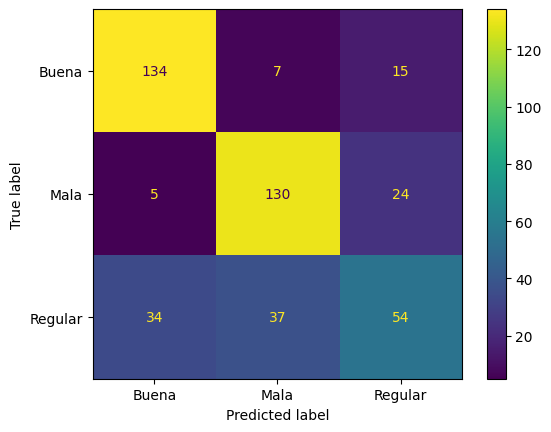

In [14]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
)

disp.plot()
plt.show()


## 11. Importancia de variables

In [15]:

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": pipeline.named_steps["model"].feature_importances_
})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

importancias


,Variable,Importancia
0,CONDUCTIVIDAD ELÉCTRICA (µS/cm),0.122734
1,ALCALINIDAD TOTAL (mg CaCO3/l),0.095722
2,BICARBONATOS (mg CaCO3/l),0.084082
3,DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l),0.072438
4,CLORUROS (mg Cl/l),0.066450
6,SODIO TOTAL (mg Na/l),0.065815
5,DUREZA CALCICA (mg CaCO3/l),0.062773
9,TURBIEDAD (UNT),0.059873
10,SULFATOS (mg SO4/l),0.056998
7,DUREZA TOTAL (mg CaCO3/l),0.055928


## 12. Exportación del modelo

In [16]:

joblib.dump(
    pipeline,
    "../models/water_quality_pipeline.joblib"
)

print("Modelo exportado correctamente.")


Modelo exportado correctamente.
